# 3 - SARSA vs Q-learning

## Problem Definition

A mobile robot operating in a risky environment must learn safe navigation policies. 

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def epsilon_greedy_action(q_table, state, epsilon, n_actions):
    """Select action using epsilon-greedy strategy."""
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)
    return np.argmax(q_table[state, :])


def train_q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """Off-policy Q-Learning implementation."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_table = np.zeros((n_states, n_actions))
    rewards_history = []

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy_action(q_table, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Off-policy update: max over all possible actions in next state
            td_target = reward + gamma * np.max(q_table[next_state, :]) * (not done)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards_history.append(total_reward)

    return q_table, rewards_history


def train_sarsa(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    """On-policy SARSA implementation."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_table = np.zeros((n_states, n_actions))
    rewards_history = []

    for _ in range(episodes):
        state, _ = env.reset()
        # Choose initial action using current epsilon-greedy policy
        action = epsilon_greedy_action(q_table, state, epsilon, n_actions)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # On-policy action selection: choose next_action via same policy
            next_action = epsilon_greedy_action(q_table, next_state, epsilon, n_actions)

            # On-policy update: use value of the action actually chosen
            td_target = reward + gamma * q_table[next_state, next_action] * (not done)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            action = next_action
            total_reward += reward

        rewards_history.append(total_reward)

    return q_table, rewards_history

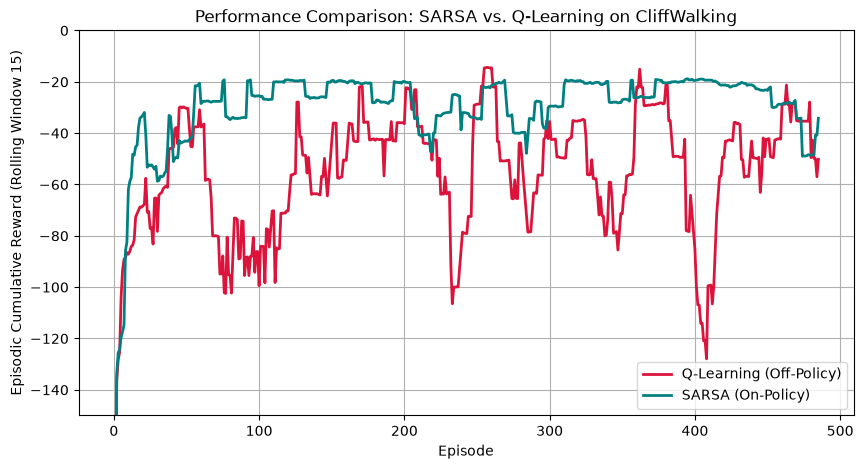

In [4]:
# Environment: CliffWalking-v1 (4x12 grid: Start at bottom-left, Goal at bottom-right, Cliff in between)
env = gym.make("CliffWalking-v1")

episodes = 500
alpha = 0.5
gamma = 1.0
epsilon = 0.1

# Run experiments across multiple seeds for smooth, robust curves
np.random.seed(42)
q_table_ql, ql_rewards = train_q_learning(
    env, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon
)
q_table_sarsa, sarsa_rewards = train_sarsa(
    env, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon
)

# Smooth rewards using rolling average
window = 15
ql_smoothed = np.convolve(ql_rewards, np.ones(window) / window, mode="valid")
sarsa_smoothed = np.convolve(sarsa_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 5))
plt.plot(ql_smoothed, label="Q-Learning (Off-Policy)", color="crimson", linewidth=2)
plt.plot(sarsa_smoothed, label="SARSA (On-Policy)", color="teal", linewidth=2)
plt.title("Performance Comparison: SARSA vs. Q-Learning on CliffWalking")
plt.xlabel("Episode")
plt.ylabel(f"Episodic Cumulative Reward (Rolling Window {window})")
plt.ylim(-150, 0)
plt.legend()
plt.grid(True)
plt.show()

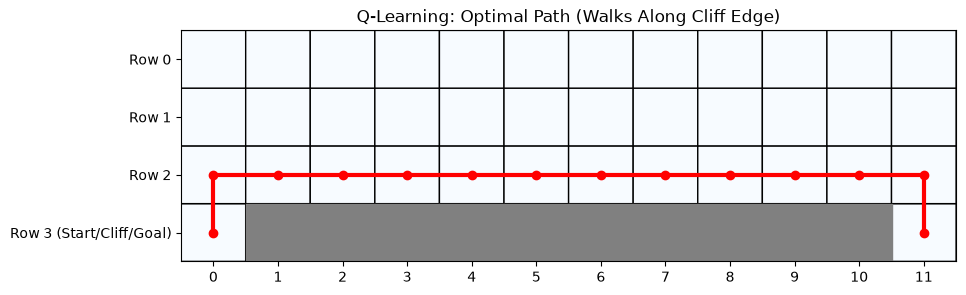

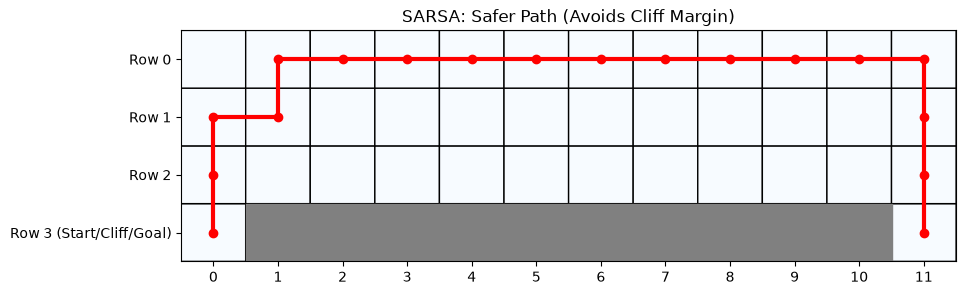

In [5]:
def visualize_trajectory(q_table, title):
    # Action map: 0: Up, 1: Right, 2: Down, 3: Left
    action_deltas = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    grid = np.zeros((4, 12))

    # Trace greedy trajectory
    pos = (3, 0)
    path = [pos]
    for _ in range(30):
        state_idx = pos[0] * 12 + pos[1]
        action = np.argmax(q_table[state_idx, :])
        dr, dc = action_deltas[action]
        pos = (min(max(pos[0] + dr, 0), 3), min(max(pos[1] + dc, 0), 11))
        path.append(pos)
        if pos == (3, 11):  # Reached Goal
            break

    # Plot grid map
    plt.figure(figsize=(10, 3))
    plt.pcolor(grid, cmap="Blues", edgecolors="k", linewidths=1)

    # Mark cliff, start, goal
    for c in range(1, 11):
        plt.fill_between([c, c + 1], [0, 0], [1, 1], color="gray", hatch="//")

    # Unpack coordinates (invert row for correct plot orientation)
    rows, cols = zip(*path)
    plt.plot(
        [c + 0.5 for c in cols],
        [3.5 - r for r in rows],
        marker="o",
        color="red",
        linewidth=3,
    )
    plt.title(title)
    plt.xticks(np.arange(12) + 0.5, [str(i) for i in range(12)])
    plt.yticks(
        [0.5, 1.5, 2.5, 3.5], ["Row 3 (Start/Cliff/Goal)", "Row 2", "Row 1", "Row 0"]
    )
    plt.show()


visualize_trajectory(q_table_ql, "Q-Learning: Optimal Path (Walks Along Cliff Edge)")
visualize_trajectory(q_table_sarsa, "SARSA: Safer Path (Avoids Cliff Margin)")

## Performance Analysis & Conclusion: SARSA vs. Q-Learning

### 1. Online Learning Performance Comparison (Figure 1)
* **SARSA (On-Policy):** Rapidly converges to an average return of approximately $-20$ and maintains steady performance throughout training. Because SARSA updates values based on the actions actually selected by its $\epsilon$-greedy exploration policy, it internalizes the risk of occasional random actions and routes itself away from danger.
* **Q-Learning (Off-Policy):** Exhibits severe negative drops down to $-100$ and $-130$ throughout the training process. While Q-learning targets the mathematically shortest path, running an exploratory policy along the cliff boundary frequently causes the agent to fall off the cliff during online execution.

### 2. Policy Trajectory & Safety Evaluation (Figure 2)
* **Q-Learning Trajectory:** Steps directly along **Row 2**—the row immediately adjacent to the cliff cells. The learned policy minimizes the number of steps (13 steps total), but has zero tolerance for exploratory deviations.
* **SARSA Trajectory (Safety Bias):** By factoring in the exploratory nature of the behavior policy, SARSA chooses a longer, conservative route (moving further up into Row 1 or Row 0) to avoid the cliff margin. Even though this path requires additional steps, it avoids catastrophic $-100$ penalties during ongoing exploration.

### 3. Conclusion
* **Algorithm Distinction:** SARSA is an **on-policy** algorithm that optimizes the value of the policy being executed (including exploration noise), whereas Q-Learning is an **off-policy** algorithm that optimizes the target greedy policy regardless of behavior actions.
* **Practical Selection:** 
  * In simulations where failure carries no physical consequence, **Q-Learning** is preferred because it converges to the truly optimal shortest path.
  * In safety-critical physical systems (e.g., autonomous mobile robots, warehouse machinery, or chemical processes), **SARSA** is superior during learning because it inherently penalizes trajectories with high disaster probability under noisy or exploratory conditions.

## Key Questions

### 1. What makes SARSA an on-policy algorithm?
* SARSA uses the tuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ to update its Q-table.
* It is **on-policy** because it updates its state-action value based on the action $A_{t+1}$ that was **actually executed** by the current behavior policy ($\epsilon$-greedy), accounting for the probability of taking random exploration steps.

### 2. How does SARSA differ from Q-Learning?
* **SARSA (On-Policy):**
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)]$$
  Evaluates the policy currently generating the behavior, including exploration mistakes.
* **Q-Learning (Off-Policy):**
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha [R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)]$$
  Evaluates the target optimal greedy policy ($\max_a$) regardless of which action was actually chosen during exploration.

### 3. Why can SARSA learn safer policies?
* In hazardous environments (like Cliff Walking), an agent choosing an action right next to a danger zone risks falling due to the $\epsilon$-greedy exploratory moves.
* Because SARSA updates using the actual chosen next action ($A_{t+1}$), it factors in the $-100$ cliff penalty that occurs during accidental exploration. Consequently, SARSA routes the agent around the cliff with a wider safety margin.
* Q-learning assumes optimal future moves ($\max_a$) and walks right along the cliff edge, which causes frequent catastrophic drops whenever $\epsilon$ triggers a random exploratory step.

### 4. How does action selection influence updates?
* In **Q-Learning**, action selection determines only which transitions are sampled, but the update target is independent of the action selected at $S_{t+1}$.
* In **SARSA**, the update target is directly dependent on the selection mechanism (e.g., $\epsilon$-greedy) at $S_{t+1}$. If exploration is active, the expected target value is lower near boundaries, actively pulling the agent toward safer areas.

---

## Supplementary Problems Analysis

* **Policy Safety Evaluation:** SARSA achieves a higher average online reward ($\approx -20$ to $-30$) during training than Q-Learning ($\approx -50$ to $-100$) because it avoids falling off the cliff during ongoing exploration.
* **Hazardous States:** In safety-critical applications (e.g., physical robotics, industrial machinery), on-policy methods like SARSA are preferred to protect equipment from catastrophic exploratory actions.